In [1]:
import os
from pathlib import Path

import matplotlib as mpl
import numpy as np
import pandas as pd
import xarray as xr

from stuff_f import (
    add_river_coordinates,
    fill_nans_with_nearest,
    get_river_indices,
    reformat_river_dataset,
    regrid_from_norkyst,
)

### Regridding
Open the downloaded datasets and regrid them to the coordinates from a bathymetry file.

In [2]:
FILES = sorted(
    os.path.join(Path.home(), "src" , "oslofjord-sim" , "data" , "input" , "NorKyst", f)
    for f in os.listdir(os.path.join(Path.home(), "src" , "oslofjord-sim" , "data" , "input" , "NorKyst"))
    if f.startswith("NorKyst-800m_ZDEPTHS_avg_")
)

In [4]:
ds_grid = xr.open_dataset(os.path.join(Path.home(), "src" , "oslofjord-sim" , "data" , "input" , "bathymetry_25to70.nc")) # "bathymetry_105to232.nc"))

In [5]:
lat_diff = np.diff(ds_grid["lat"].values)[0]
lat_faces = np.zeros(shape=ds_grid["lat"].values.shape[0] + 1)
lat_faces[0] = ds_grid["lat"].values[0] - lat_diff / 2
lat_faces[1:] = ds_grid["lat"].values + lat_diff / 2

In [6]:
lon_diff = np.diff(ds_grid["lon"].values)[0]
lon_faces = np.zeros(shape=ds_grid["lon"].values.shape[0] + 1)
lon_faces[0] = ds_grid["lon"].values[0] - lon_diff / 2
lon_faces[1:] = ds_grid["lon"].values + lon_diff / 2

In [7]:
z_faces = ds_grid.z_faces.values
z_centers = [(z_faces[i] + z_faces[i + 1]) / 2 for i in range(len(z_faces) - 1)]
ds_out_c = xr.Dataset(
    {
        "lat": (["lat"], ds_grid["lat"].values, {"units": "degrees_north"}),
        "lon": (["lon"], ds_grid["lon"].values, {"units": "degrees_east"}),
    }
)
ds_out_u = xr.Dataset(
    {
        "lat": (["lat"], ds_grid["lat"].values, {"units": "degrees_north"}),
        "lon": (["lon"], lon_faces, {"units": "degrees_east"}),
    }
)
ds_out_v = xr.Dataset(
    {
        "lat": (["lat"], lat_faces, {"units": "degrees_north"}),
        "lon": (["lon"], ds_grid["lon"].values, {"units": "degrees_east"}),
    }
)

In [8]:
time_list = []
temp_list = []
salt_list = []
u_list = []
v_list = []

regridder_rho, regridder_u, regridder_v = None, None, None
for file in FILES:
    ds_in = xr.open_dataset(file)
    new_time = pd.date_range(start=ds_in.time[0].values, end=ds_in.time[-1].values, freq="D")
    ds_in = ds_in.reindex(time=new_time, method="ffill")
    regridder_rho, regridder_u, regridder_v, np_time, np_temp, np_salt, np_u, np_v = regrid_from_norkyst(
        regridder_rho, regridder_u, regridder_v, ds_in, ds_out_c, ds_out_u, ds_out_v, np.array(z_centers)
    )
    time_list.append(np_time)
    temp_list.append(np_temp)
    salt_list.append(np_salt)
    u_list.append(np_u)
    v_list.append(np_v)
    print(f"File {file} processed.")

File /home/eya/src/oslofjord-sim/data/input/NorKyst/NorKyst-800m_ZDEPTHS_avg_202001.nc processed.
File /home/eya/src/oslofjord-sim/data/input/NorKyst/NorKyst-800m_ZDEPTHS_avg_202002.nc processed.
File /home/eya/src/oslofjord-sim/data/input/NorKyst/NorKyst-800m_ZDEPTHS_avg_202003.nc processed.
File /home/eya/src/oslofjord-sim/data/input/NorKyst/NorKyst-800m_ZDEPTHS_avg_202004.nc processed.
File /home/eya/src/oslofjord-sim/data/input/NorKyst/NorKyst-800m_ZDEPTHS_avg_202005.nc processed.
File /home/eya/src/oslofjord-sim/data/input/NorKyst/NorKyst-800m_ZDEPTHS_avg_202006.nc processed.
File /home/eya/src/oslofjord-sim/data/input/NorKyst/NorKyst-800m_ZDEPTHS_avg_202007.nc processed.
File /home/eya/src/oslofjord-sim/data/input/NorKyst/NorKyst-800m_ZDEPTHS_avg_202008.nc processed.
File /home/eya/src/oslofjord-sim/data/input/NorKyst/NorKyst-800m_ZDEPTHS_avg_202009.nc processed.
File /home/eya/src/oslofjord-sim/data/input/NorKyst/NorKyst-800m_ZDEPTHS_avg_202010.nc processed.
File /home/eya/src/o

In [9]:
np_time = np.concatenate(time_list, axis=0)
np_temp = np.concatenate(temp_list, axis=0).astype(np.float32)
np_salt = np.concatenate(salt_list, axis=0).astype(np.float32)
np_u = np.concatenate(u_list, axis=0).astype(np.float32)
np_v = np.concatenate(v_list, axis=0).astype(np.float32)

In [10]:
Tout_lambda = np.zeros_like(np_temp)
Sout_lambda = np.zeros_like(np_salt)
Uout_lambda = np.zeros_like(np_u)
Vout_lambda = np.zeros_like(np_v)

In [11]:
dsout = xr.Dataset(
    {
        "T": (["time", "Nz", "Ny", "Nx"], np_temp),
        "T_lambda": (["time", "Nz", "Ny", "Nx"], Tout_lambda),
        "S": (["time", "Nz", "Ny", "Nx"], np_salt),
        "S_lambda": (["time", "Nz", "Ny", "Nx"], Sout_lambda),
        "u": (["time", "Nz", "Ny", "Nx_faces"], np_u),
        "u_lambda": (["time", "Nz", "Ny", "Nx_faces"], Uout_lambda),
        "v": (["time", "Nz", "Ny_faces", "Nx"], np_v),
        "v_lambda": (["time", "Nz", "Ny_faces", "Nx"], Vout_lambda),
    },
    coords={
        "time": np_time,
        "Nz": z_centers,
        "Nz_faces": z_faces,
        "Ny": ds_grid["lat"].values,
        "Ny_faces": lat_faces,
        "Nx": ds_grid["lon"].values,
        "Nx_faces": lon_faces,
    },
)

In [12]:
dsout

<xarray.Dataset> Size: 270MB
Dimensions:   (time: 366, Nz: 13, Ny: 70, Nx: 25, Nx_faces: 26, Ny_faces: 71,
               Nz_faces: 14)
Coordinates:
  * time      (time) datetime64[ns] 3kB 2020-01-01T12:00:00 ... 2020-12-31T12...
  * Nz        (Nz) float64 104B -262.5 -275.0 -150.0 -62.5 ... -2.5 -1.5 -0.5
  * Ny        (Ny) float64 560B 59.64 59.64 59.65 59.65 ... 59.91 59.92 59.92
  * Nx        (Nx) float64 200B 10.46 10.47 10.49 10.5 ... 10.76 10.78 10.79
  * Nx_faces  (Nx_faces) float64 208B 10.45 10.47 10.48 ... 10.77 10.78 10.8
  * Ny_faces  (Ny_faces) float64 568B 59.64 59.64 59.65 ... 59.91 59.92 59.92
  * Nz_faces  (Nz_faces) float64 112B -200.0 -325.0 -225.0 ... -2.0 -1.0 0.0
Data variables:
    T         (time, Nz, Ny, Nx) float32 33MB nan nan nan nan ... nan nan nan
    T_lambda  (time, Nz, Ny, Nx) float32 33MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    S         (time, Nz, Ny, Nx) float32 33MB nan nan nan nan ... nan nan nan
    S_lambda  (time, Nz, Ny, Nx) float32 33MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    u         (time, Nz, Ny, Nx_faces) float32 35MB nan nan nan ... nan nan nan
    u_lambda  (time, Nz, Ny, Nx_faces) float32 35MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    v         (time, Nz, Ny_faces, Nx) float32 34MB nan nan nan ... nan nan nan
    v_lambda  (time, Nz, Ny_faces, Nx) float32 34MB 0.0 0.0 0.0 ... 0.0 0.0 0.0

In [13]:
z_level = -1

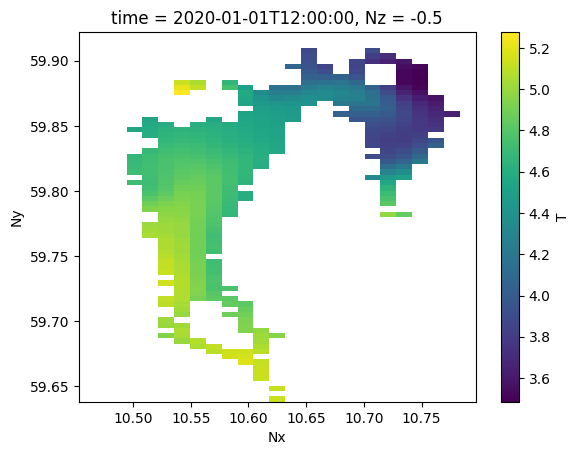

In [14]:
dsout.T.isel(time=0, Nz=z_level).plot()

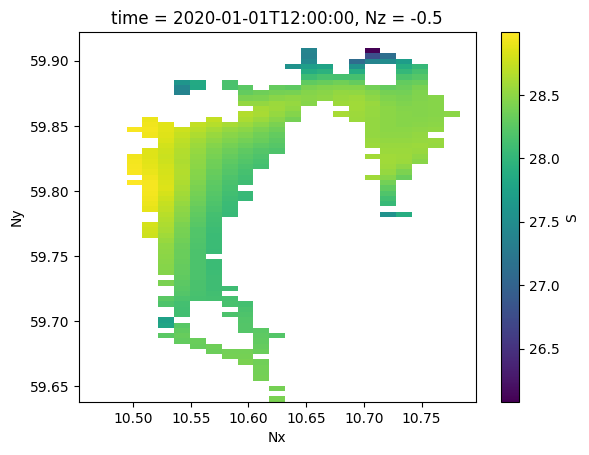

In [15]:
dsout.S.isel(time=0, Nz=z_level).plot()

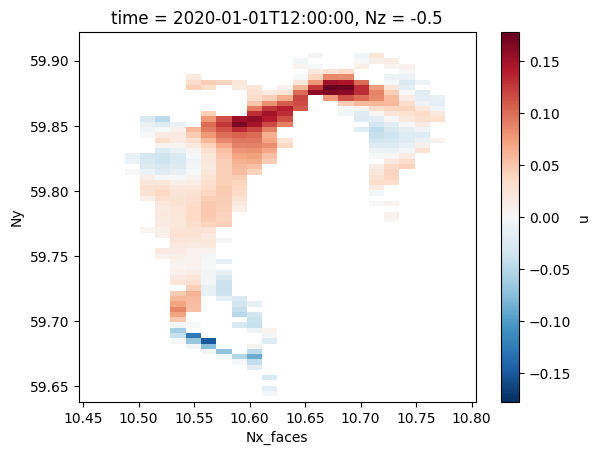

In [16]:
dsout.u.isel(time=0, Nz=z_level).plot()

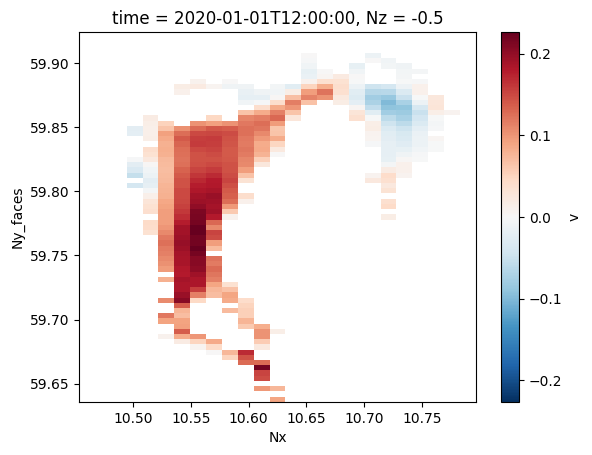

In [17]:
dsout.v.isel(time=0, Nz=z_level).plot()

### Prepare the forcing dataset

In [18]:
ds = dsout.copy(deep=True)

In [19]:
np_z_centers = (ds_grid.z_faces.values[:-1] + ds_grid.z_faces.values[1:]) / 2
oy, ox, oz = (value for value in ds_grid.sizes.values())
np_mask = (np_z_centers > ds_grid.h.values[..., np.newaxis]).astype(int).transpose(2, 0, 1)

In [20]:
np_mask_u = np.zeros((oz - 1, oy, ox + 1))
np_mask_u[:, :, :-1] = np_mask
np_mask_u[:, :, 1:] = np.where(np_mask_u[:, :, 1:] == 0, np_mask, np_mask_u[:, :, 1:])

In [21]:
np_mask_v = np.zeros((oz - 1, oy + 1, ox))
np_mask_v[:, :-1, :] = np_mask
np_mask_v[:, 1:, :] = np.where(np_mask_v[:, 1:, :] == 0, np_mask, np_mask_v[:, 1:, :])

In [22]:
ds.T.values = fill_nans_with_nearest(ds.T) * np_mask
ds.S.values = fill_nans_with_nearest(ds.S) * np_mask
ds.u.values = fill_nans_with_nearest(ds.u) * np_mask_u
ds.v.values = fill_nans_with_nearest(ds.v) * np_mask_v

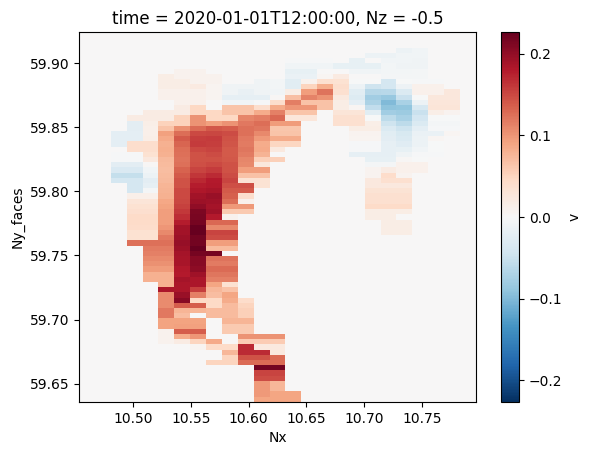

In [23]:
ds.v.isel(time=0, Nz=-1).plot()

Check once again for data gaps in the downloaded datasets

In [24]:
ds = ds.sortby("time")

In [25]:
ds

<xarray.Dataset> Size: 405MB
Dimensions:   (time: 366, Nz: 13, Ny: 70, Nx: 25, Nx_faces: 26, Ny_faces: 71,
               Nz_faces: 14)
Coordinates:
  * time      (time) datetime64[ns] 3kB 2020-01-01T12:00:00 ... 2020-12-31T12...
  * Nz        (Nz) float64 104B -262.5 -275.0 -150.0 -62.5 ... -2.5 -1.5 -0.5
  * Ny        (Ny) float64 560B 59.64 59.64 59.65 59.65 ... 59.91 59.92 59.92
  * Nx        (Nx) float64 200B 10.46 10.47 10.49 10.5 ... 10.76 10.78 10.79
  * Nx_faces  (Nx_faces) float64 208B 10.45 10.47 10.48 ... 10.77 10.78 10.8
  * Ny_faces  (Ny_faces) float64 568B 59.64 59.64 59.65 ... 59.91 59.92 59.92
  * Nz_faces  (Nz_faces) float64 112B -200.0 -325.0 -225.0 ... -2.0 -1.0 0.0
Data variables:
    T         (time, Nz, Ny, Nx) float64 67MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    T_lambda  (time, Nz, Ny, Nx) float32 33MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    S         (time, Nz, Ny, Nx) float64 67MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    S_lambda  (time, Nz, Ny, Nx) float32 33MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    u         (time, Nz, Ny, Nx_faces) float64 69MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    u_lambda  (time, Nz, Ny, Nx_faces) float32 35MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    v         (time, Nz, Ny_faces, Nx) float64 68MB -0.0 -0.0 -0.0 ... -0.0 -0.0
    v_lambda  (time, Nz, Ny_faces, Nx) float32 34MB 0.0 0.0 0.0 ... 0.0 0.0 0.0

In [26]:
new_time = pd.date_range(start=ds.time[0].values, end=ds.time[-1].values, freq="D")
new_time[~new_time.isin(ds.time.values)]  # this shows which dates are missing in the original data

DatetimeIndex([], dtype='datetime64[ns]', freq='D')

In [27]:
ds = ds.reindex(time=new_time, method="ffill")

Fill in lambdas for the sourthern boundary conditions.
Lambdas that -1 < lambda < 1 are relaxation rates.
Lambdas > 2 mean flux in x direction (west to east).
Lambdas < -1 mean flux in y direction (south to north).

In [33]:
southern_edge = 7 #10  # use relaxation at 10 southernmost 'layers' at all depths
lambda_relaxation = 1 / (300 * 300) / 5  #1 / (60 * 60 * 24)

In [34]:
ds["NUT"] = (["time", "Nz", "Ny", "Nx"], np.zeros_like(ds.T.values))
ds["NUT_lambda"] = (["time", "Nz", "Ny", "Nx"], np.zeros_like(ds.T_lambda.values))
ds["DOM"] = (["time", "Nz", "Ny", "Nx"], np.zeros_like(ds.T.values))
ds["DOM_lambda"] = (["time", "Nz", "Ny", "Nx"], np.zeros_like(ds.T_lambda.values))
ds["POM"] = (["time", "Nz", "Ny", "Nx"], np.zeros_like(ds.T.values))
ds["POM_lambda"] = (["time", "Nz", "Ny", "Nx"], np.zeros_like(ds.T_lambda.values))
ds["Ci_free"] = (["time", "Nz", "Ny", "Nx"], np.zeros_like(ds.T.values))
ds["Ci_free_lambda"] = (["time", "Nz", "Ny", "Nx"], np.zeros_like(ds.T_lambda.values))
ds["C"] = (["time", "Nz", "Ny", "Nx"], np.zeros_like(ds.T.values))
ds["C_lambda"] = (["time", "Nz", "Ny", "Nx"], np.zeros_like(ds.T_lambda.values))

In [35]:
ds["T_lambda"][:, :, :southern_edge, :] = (lambda_relaxation) * np_mask[:, :southern_edge, :]
ds["T_lambda"] = ds["T_lambda"].astype(np.float32)
ds["S_lambda"][:, :, :southern_edge, :] = (lambda_relaxation) * np_mask[:, :southern_edge, :]
ds["S_lambda"] = ds["S_lambda"].astype(np.float32)
ds["u_lambda"][:, :, :southern_edge, :] = (lambda_relaxation) * np_mask_u[:, :southern_edge, :]
ds["u_lambda"] = ds["u_lambda"].astype(np.float32)
ds["v_lambda"][:, :, :southern_edge, :] = (lambda_relaxation) * np_mask_v[:, :southern_edge, :]
ds["v_lambda"] = ds["v_lambda"].astype(np.float32)
ds["NUT_lambda"][:, :, :southern_edge, :] = (lambda_relaxation) * np_mask[:, :southern_edge, :]
ds["NUT_lambda"] = ds["NUT_lambda"].astype(np.float32)
ds["DOM_lambda"][:, :, :southern_edge, :] = (lambda_relaxation) * np_mask[:, :southern_edge, :]
ds["DOM_lambda"] = ds["DOM_lambda"].astype(np.float32)
ds["POM_lambda"][:, :, :southern_edge, :] = (lambda_relaxation) * np_mask[:, :southern_edge, :]
ds["POM_lambda"] = ds["POM_lambda"].astype(np.float32)
ds["Ci_free_lambda"][:, :, :southern_edge, :] = (lambda_relaxation) * np_mask[:, :southern_edge, :]
ds["Ci_free_lambda"] = ds["Ci_free_lambda"].astype(np.float32)


In [36]:
ds["T"][:, :, :, :] = np.where(np_mask == 0, np.nan, np_mask) * ds["T"][:, :, :, :]
ds["S"][:, :, :, :] = np.where(np_mask == 0, np.nan, np_mask) * ds["S"][:, :, :, :]
ds["NUT"][:, :, :, :] = np.where(np_mask == 0, np.nan, np_mask) * ds["NUT"][:, :, :, :]
ds["DOM"][:, :, :, :] = np.where(np_mask == 0, np.nan, np_mask) * ds["DOM"][:, :, :, :]
ds["POM"][:, :, :, :] = np.where(np_mask == 0, np.nan, np_mask) * ds["POM"][:, :, :, :]
ds["Ci_free"][:, :, :, :] = np.where(np_mask == 0, np.nan, np_mask) * ds["Ci_free"][:, :, :, :]
ds["C"][:, :, :, :] = np.where(np_mask == 0, np.nan, np_mask) * ds["C"][:, :, :, :]
ds["u"][:, :, :, :] = np.where(np_mask_u == 0, np.nan, np_mask_u) * ds["u"][:, :, :, :]
ds["v"][:, :, :, :] = np.where(np_mask_v == 0, np.nan, np_mask_v) * ds["v"][:, :, :, :]

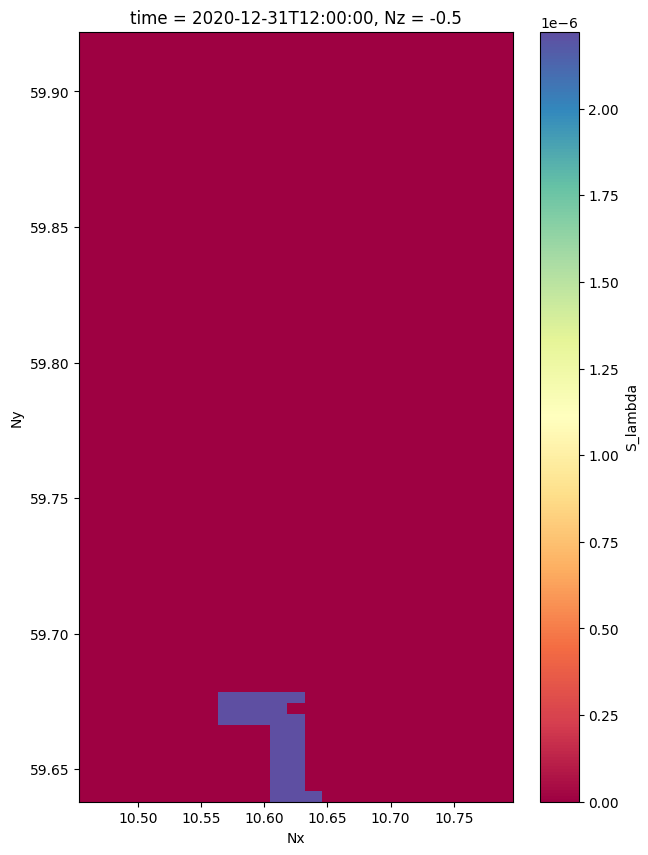

In [37]:
ds
ds.S_lambda.isel(time=-1, Nz=-1).plot(cmap=mpl.colormaps.get_cmap("Spectral"), figsize=(7, 10))

In [38]:
def fill_bgh_var(df, da, repeat=None):
    arr = df.values[:, 1:]
    arr = arr[:, ::-1]
    if repeat is None:
        repeat = max(0, da.shape[1] - arr.shape[1])
    first_col = arr[:, [0]]
    extra_cols = np.repeat(first_col, repeat, axis=1)
    arr = np.hstack((extra_cols, arr))  # add bottom layers
    arr = arr[:, :da.shape[1]]  # trim to match target depth levels
    arr = np.vstack((arr, arr[[-1], :]))  # add the last day
    arr = arr[:, :, None, None]
    arr = np.tile(arr, (1, 1, da.shape[2], da.shape[3]))
    return xr.DataArray(arr, dims=da.dims, coords=da.coords, attrs=da.attrs).astype(np.float32)

In [39]:

DATA_INPUT = Path.home() / "src" / "oslofjord-sim" / "data" / "input"
df_NUT = pd.read_csv(DATA_INPUT / "Sea_boundary" / "NUT.csv", sep=";")
ds["NUT"] = fill_bgh_var(df_NUT, ds["S"])
# ds_new["NUT"] = fill_bgh_var(df_NUT, ds_new["S"])
# ds_new["NUT_lambda"] = ds_new["sea_lambda"]
ds["Ci_free"] = xr.full_like(ds["T"], fill_value=0.01, dtype=np.float32)
ds["NUT"]
DATA_INPUT


PosixPath('/home/eya/src/oslofjord-sim/data/input')

In [40]:
def get_river(file_name, layers_num=3):
    df_BGC_variable = pd.read_csv(
        DATA_INPUT / "Rivers" / file_name, sep=";", skiprows=1
    )
    df = df_BGC_variable
    #  read concentration (mmol/m3) in the file column 3 (i.e. 2 in python) or  discharge (mmol/s) from the  column 4(3)
    arr = 1.0 * np.abs(df.values[:, 2]) # NON-DOUBLED CONCENTrATION,  TRIPPLE!!!
    #  make the array  arr with dimensions corresponding to the number of layers 
    arr = np.repeat(arr[:, None], layers_num, axis=1)
    # pad to 366 rows for leap years by repeating last row
    n_times = ds.sizes["time"]
    if arr.shape[0] < n_times:
        pad = np.repeat(arr[[-1], :], n_times - arr.shape[0], axis=0)
        arr = np.vstack([arr, pad])
    return arr

def get_river_dis(file_name, column, layers_num=3):
    df_water_discharge = pd.read_csv(
        DATA_INPUT / "Rivers" / file_name, sep=";", skiprows=1
    )
    df = df_water_discharge
    #  read water discharge (m3/s) in the file column 2 (i.e. 1 in python)
    arr = np.abs(df.values[:, column]) 
    #  make the array  arr with dimensions corresponding to the number of layers 
    arr = np.repeat(arr[:, None], layers_num, axis=1)
    # pad to 366 rows for leap years by repeating last row
    n_times = ds.sizes["time"]
    if arr.shape[0] < n_times:
        pad = np.repeat(arr[[-1], :], n_times - arr.shape[0], axis=0)
        arr = np.vstack([arr, pad])
    return arr

# river lambda is needed to convert the fluxes (in umol/s) to concentration 
# tendencies (in umol/m^3/s). We divide the discharge by the volume 
# of the model grid. Here we calculate the model grid volume assuming that the 
# river water occupies an area (dx=300m X dy=300m) and depth (dz[1:3]=3m) in the 
# model grid. Further this value should be multplied by the water discharge (m^3/s).
# 

river_lambda = 1 / (300 * 300) / 3   # 1 per hour ! 
#river_lambda = 1 / (300 * 300) / 3 #/ 1200  # 1 per hour ! 
#river_lambda = 1 / (60 * 60) /600 #/ 1200  # 1 per hour ! 


### Add rivers

In [41]:
ds_rivers = xr.open_dataset(os.path.join(Path.home(), "src" , "oslofjord-sim" , "data" , "input" , "of800_rivers_v9_1990_2022_RA1.nc"))
ds_rivers = ds_rivers.isel(s_rho=-1)  # all layers data is the same, keep only 1
ds_rivers = ds_rivers.assign_coords(river=np.arange(1, 26))

Refactor a rivers dataset for convenience

In [42]:
ds_rivers = reformat_river_dataset(ds_rivers)

Add rivers coordinates from another file

In [43]:
df_rivers = pd.read_csv(os.path.join(Path.home(), "src" , "oslofjord-sim" , "data" , "input" , "OF800_rivers.csv"))
ds_rivers = add_river_coordinates(ds_rivers, df_rivers)

In [44]:
surface_mask = np_mask[-1, :, :]

Fill in river_indices with valid cell y, x coordinates

In [45]:
river_indices = get_river_indices(ds, ds_rivers, surface_mask)

Processing river (1,) original location (58.9271, 11.106) validity: 58.9271 is outside of 59.64; 59.92
Processing river (2,) original location (59.0826, 11.2234) validity: 59.0826 is outside of 59.64; 59.92
Processing river (3,) original location (59.0887, 11.2306) validity: 59.0887 is outside of 59.64; 59.92
Processing river (4,) original location (59.1859, 10.9709) validity: 59.1859 is outside of 59.64; 59.92
Processing river (5,) original location (59.1798, 10.9638) validity: 59.1798 is outside of 59.64; 59.92
Processing river (6,) original location (59.1773, 10.9446) validity: 59.1773 is outside of 59.64; 59.92
Processing river (7,) original location (59.1712, 10.9375) validity: 59.1712 is outside of 59.64; 59.92
Processing river (8,) original location (59.1859, 10.8896) validity: 59.1859 is outside of 59.64; 59.92
Processing river (9,) original location (59.1822, 10.9016) validity: 59.1822 is outside of 59.64; 59.92
Processing river (10,) original location (59.5023, 10.6713) valid

Put rivers into the forcing dataset

In [ ]:
#temperature_idx = list(ds_rivers.properties).index("river_temp")
#nitrate_idx = list(ds_rivers.properties).index("river_N3_n")
"""
for river_num, (y, x) in river_indices.items():
    ds_river = ds_rivers.sel(river_number=river_num)
    temperature = ds_river.rivers.isel(properties=temperature_idx).sel(river_time=slice("2020-01-01", "2020-12-31"))
    ds["T"].values[:, -1, y, x] = temperature.values
    ds["T"][:, :, :, :] = np.where(np_mask == 0, np.nan, np_mask) * ds["T"][:, :, :, :]
    ds["T_lambda"].values[:, -1, y, x] = 1 / (60 * 60)
    ds["S"].values[:, -1, y, x] = 0
    ds["S"][:, :, :, :] = np.where(np_mask == 0, np.nan, np_mask) * ds["S"][:, :, :, :]
    ds["S_lambda"].values[:, -1, y, x] = 1 / (60 * 60)
    nitrate = ds_river.rivers.isel(properties=nitrate_idx).sel(river_time=slice("2020-01-01", "2020-12-31"))
    ds["NUT"].values[:, -1, y, x] = nitrate.values
    ds["NUT"][:, :, :, :] = np.where(np_mask == 0, np.nan, np_mask) * ds["NUT"][:, :, :, :]
    ds["NUT_lambda"].values[:, -1, y, x] = 1 / (60 * 60)
    
#ds.S.isel(time=-1, Nz=-1, Ny=slice(215, 225), Nx=slice(40, 50)).plot(cmap=mpl.colormaps.get_cmap("Spectral"))
    #ds.S_lambda.isel(time=-1, Nz=-1).where(lambda x: x != 0).plot(cmap=mpl.colormaps.get_cmap("Spectral"), figsize=(7, 10))
    """ 

In [ ]:

# SANK BOAT",
"""
boat_lambda =  - 9 / (300 * 300) / 1  # cell volume 300*300*1 m 
ds["Ci_free"].values[:, 11, 185, 10] =  0.2 # 0.2 mg/s correcponds to 1000 kg dissolustion with t(1/2) = 100 yrs
ds["Ci_free_lambda"].values[:, 11, 185, 10] = boat_lambda,
ds["Ci_free"].values[:, 12, 220, 45] =  0.2 # 0.2 mg/s correcponds to 1000 kg dissolustion with t(1/2) = 100 yrs
ds["Ci_free_lambda"].values[:, 12, 220, 45] = boat_lambda,
ds["Ci_free"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["Ci_free"][:, :, :, :])
"""
#ds["C"][:, 11, 185, 10] = 1.0
#ds["C_lambda"].values[:, 11, 185, 10] = 1 / (60 * 60)
#ds["C"][:, 12, 220, 45] = 1.0
#ds["C_lambda"].values[:, 12, 220, 45] = 1 / (60 * 60)

In [ ]:
#ds.C.isel(time=-1, Nz=12).plot(cmap=mpl.colormaps.get_cmap("Spectral"), figsize=(7, 10))

In [ ]:
""" 
# SOUTH from INNER OSLOFJORDEN
# elva (#4)
y, x = 46, 96  
layers_num = 3 # y,x - coordinates of the river mouth in the large Oslo fjord grid
# u_lambda = 2 for horizontal (W-E)  =-2 for vertical (N-S)
# u =-0.5 directed from N to S  river_N3_n_from_3_year_2020.csv
ds["v"].values[:, -layers_num:, y + 1, x] = get_river_dis("river_N3_n_from_4_year_2020.csv", 1, layers_num=layers_num)/layers_num # negative flux means 'to the south'
ds["v_lambda"].values[:, -layers_num:, y + 1, x] =  -2   # this lambda means flux in 'y' direction
ds["v"][:, :, :, :] = (np.where(np_mask_v == 0, np.nan, np_mask_v) * ds["v"][:, :, :, :])
ds["S"].values[:, -layers_num:, y, x] =  get_river("river_S_from_4_year_2020.csv", layers_num=layers_num)
ds["S_lambda"].values[:, -layers_num:, y, x] =  river_lambda * get_river_dis("river_N3_n_from_4_year_2020.csv", 1, layers_num=layers_num)/layers_num
ds["S"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["S"][:, :, :, :])
ds["NUT"].values[:, -layers_num:, y, x] =  get_river("river_N3_n_from_4_year_2020.csv", layers_num=layers_num)
ds["NUT_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_N3_n_from_4_year_2020.csv", 1, layers_num=layers_num)/layers_num 
ds["NUT"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["NUT"][:, :, :, :])
ds["DOM"].values[:, -layers_num:, y, x] =  get_river("river_R2_n_from_4_year_2020.csv", layers_num=layers_num)
ds["DOM_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_R2_n_from_4_year_2020.csv", 1, layers_num=layers_num)/layers_num 
ds["DOM"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["DOM"][:, :, :, :])
ds["POM"].values[:, -layers_num:, y, x] =  get_river("river_PON0_from_4_year_2020.csv", layers_num=layers_num)
ds["POM_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_PON0_from_4_year_2020.csv", 1, layers_num=layers_num)/layers_num 
ds["POM"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["POM"][:, :, :, :])
ds["Ci_free"].values[:, -layers_num:, y, x] =  get_river("river_Ci_from_4_year_2020.csv", layers_num=layers_num)
ds["Ci_free_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_Ci_from_4_year_2020.csv", 1, layers_num=layers_num)/layers_num 
ds["Ci_free"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["Ci_free"][:, :, :, :])

# elva (#5)
y, x = 45, 96  
layers_num = 3 # y,x - coordinates of the river mouth in the large Oslo fjord grid
# u_lambda = 2 for horizontal (W-E)  =-2 for vertical (N-S)
# u =-0.5 directed from N to S  river_N3_n_from_3_year_2020.csv
ds["v"].values[:, -layers_num:, y + 1, x] = get_river_dis("river_N3_n_from_5_year_2020.csv", 1, layers_num=layers_num)/layers_num # negative flux means 'to the south'
ds["v_lambda"].values[:, -layers_num:, y + 1, x] =  -2   # this lambda means flux in 'y' direction
ds["v"][:, :, :, :] = (np.where(np_mask_v == 0, np.nan, np_mask_v) * ds["v"][:, :, :, :])
ds["S"].values[:, -layers_num:, y, x] =  get_river("river_S_from_5_year_2020.csv", layers_num=layers_num)
ds["S_lambda"].values[:, -layers_num:, y, x] =  river_lambda * get_river_dis("river_N3_n_from_5_year_2020.csv", 1, layers_num=layers_num)/layers_num
ds["S"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["S"][:, :, :, :])
ds["NUT"].values[:, -layers_num:, y, x] =  get_river("river_N3_n_from_5_year_2020.csv", layers_num=layers_num)
ds["NUT_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_N3_n_from_5_year_2020.csv", 1, layers_num=layers_num)/layers_num
ds["NUT"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["NUT"][:, :, :, :])
ds["DOM"].values[:, -layers_num:, y, x] =  get_river("river_R2_n_from_5_year_2020.csv", layers_num=layers_num)
ds["DOM_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_R2_n_from_5_year_2020.csv", 1, layers_num=layers_num)/layers_num 
ds["DOM"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["DOM"][:, :, :, :])
ds["POM"].values[:, -layers_num:, y, x] =  get_river("river_PON0_from_5_year_2020.csv", layers_num=layers_num)
ds["POM_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_PON0_from_5_year_2020.csv", 1, layers_num=layers_num)/layers_num 
ds["POM"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["POM"][:, :, :, :])
ds["Ci_free"].values[:, -layers_num:, y, x] =  get_river("river_Ci_from_5_year_2020.csv", layers_num=layers_num)
ds["Ci_free_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_Ci_from_5_year_2020.csv", 1, layers_num=layers_num)/layers_num 
ds["Ci_free"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["Ci_free"][:, :, :, :])

# elva (#6)
y, x = 44, 95  
layers_num = 3 # y,x - coordinates of the river mouth in the large Oslo fjord grid
# u_lambda = 2 for horizontal (W-E)  =-2 for vertical (N-S)
# u =-0.5 directed from N to S  river_N3_n_from_3_year_2020.csv
ds["v"].values[:, -layers_num:, y + 1, x] = get_river_dis("river_N3_n_from_6_year_2020.csv", 1, layers_num=layers_num)/layers_num # negative flux means 'to the south'
ds["v_lambda"].values[:, -layers_num:, y + 1, x] =  -2   # this lambda means flux in 'y' direction
ds["v"][:, :, :, :] = (np.where(np_mask_v == 0, np.nan, np_mask_v) * ds["v"][:, :, :, :])
ds["S"].values[:, -layers_num:, y, x] =  get_river("river_S_from_6_year_2020.csv", layers_num=layers_num)
ds["S_lambda"].values[:, -layers_num:, y, x] =  river_lambda * get_river_dis("river_N3_n_from_6_year_2020.csv", 1, layers_num=layers_num)/layers_num
ds["S"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["S"][:, :, :, :])
ds["NUT"].values[:, -layers_num:, y, x] =  get_river("river_N3_n_from_6_year_2020.csv", layers_num=layers_num)
ds["NUT_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_N3_n_from_6_year_2020.csv", 1, layers_num=layers_num)/layers_num 
ds["NUT"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["NUT"][:, :, :, :])
ds["DOM"].values[:, -layers_num:, y, x] =  get_river("river_R2_n_from_6_year_2020.csv", layers_num=layers_num)
ds["DOM_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_R2_n_from_6_year_2020.csv", 1, layers_num=layers_num)/layers_num 
ds["DOM"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["DOM"][:, :, :, :])
ds["POM"].values[:, -layers_num:, y, x] =  get_river("river_PON0_from_6_year_2020.csv", layers_num=layers_num)
ds["POM_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_PON0_from_6_year_2020.csv", 1, layers_num=layers_num)/layers_num 
ds["POM"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["POM"][:, :, :, :])
ds["Ci_free"].values[:, -layers_num:, y, x] =  get_river("river_Ci_from_6_year_2020.csv", layers_num=layers_num)
ds["Ci_free_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_Ci_from_6_year_2020.csv", 1, layers_num=layers_num)/layers_num 
ds["Ci_free"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["Ci_free"][:, :, :, :])

# elva (#7)
y, x = 46, 96  
layers_num = 3 # y,x - coordinates of the river mouth in the large Oslo fjord grid
# u_lambda = 2 for horizontal (W-E)  =-2 for vertical (N-S)
# u =-0.5 directed from N to S  river_N3_n_from_3_year_2020.csv
ds["v"].values[:, -layers_num:, y + 1, x] = get_river_dis("river_N3_n_from_7_year_2020.csv", 1, layers_num=layers_num)/layers_num # negative flux means 'to the south'
#ds["v_lambda"].values[:, -2:, y + 1, x] = -2  # this lambda means flux in 'y' direction
ds["v_lambda"].values[:, -layers_num:, y + 1, x] =  -2   # this lambda means flux in 'y' direction
ds["v"][:, :, :, :] = (np.where(np_mask_v == 0, np.nan, np_mask_v) * ds["v"][:, :, :, :])
ds["S"].values[:, -layers_num:, y, x] =  get_river("river_S_from_7_year_2020.csv", layers_num=layers_num)
ds["S_lambda"].values[:, -layers_num:, y, x] =  river_lambda * get_river_dis("river_N3_n_from_7_year_2020.csv", 1, layers_num=layers_num)/layers_num
ds["S"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["S"][:, :, :, :])
ds["NUT"].values[:, -layers_num:, y, x] =  get_river("river_N3_n_from_7_year_2020.csv", layers_num=layers_num)
ds["NUT_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_N3_n_from_7_year_2020.csv", 1, layers_num=layers_num)/layers_num 
ds["NUT"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["NUT"][:, :, :, :])
ds["DOM"].values[:, -layers_num:, y, x] =  get_river("river_R2_n_from_7_year_2020.csv", layers_num=layers_num)
ds["DOM_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_R2_n_from_7_year_2020.csv", 1, layers_num=layers_num)/layers_num 
ds["DOM"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["DOM"][:, :, :, :])
ds["POM"].values[:, -layers_num:, y, x] =  get_river("river_PON0_from_7_year_2020.csv", layers_num=layers_num)
ds["POM_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_PON0_from_7_year_2020.csv", 1, layers_num=layers_num)/layers_num 
ds["POM"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["POM"][:, :, :, :])
ds["Ci_free"].values[:, -layers_num:, y, x] =  get_river("river_Ci_from_7_year_2020.csv", layers_num=layers_num)
ds["Ci_free_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_Ci_from_7_year_2020.csv", 1, layers_num=layers_num)/layers_num 
ds["Ci_free"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["Ci_free"][:, :, :, :])

# elva (#8)
y, x = 46, 87  
layers_num = 3 # y,x - coordinates of the river mouth in the large Oslo fjord grid
# u_lambda = 2 for horizontal (W-E)  =-2 for vertical (N-S)
# u =-0.5 directed from N to S  river_N3_n_from_3_year_2020.csv
ds["v"].values[:, -layers_num:, y + 1, x] = get_river_dis("river_N3_n_from_8_year_2020.csv", 1, layers_num=layers_num)/layers_num # negative flux means 'to the south'
#ds["v_lambda"].values[:, -2:, y + 1, x] = -2  # this lambda means flux in 'y' direction
ds["v_lambda"].values[:, -layers_num:, y + 1, x] =  -2   # this lambda means flux in 'y' direction
ds["v"][:, :, :, :] = (np.where(np_mask_v == 0, np.nan, np_mask_v) * ds["v"][:, :, :, :])
ds["S"].values[:, -layers_num:, y, x] =  get_river("river_S_from_8_year_2020.csv", layers_num=layers_num)
ds["S_lambda"].values[:, -layers_num:, y, x] =  river_lambda * get_river_dis("river_N3_n_from_8_year_2020.csv", 1, layers_num=layers_num)/layers_num
ds["S"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["S"][:, :, :, :])
ds["NUT"].values[:, -layers_num:, y, x] =  get_river("river_N3_n_from_8_year_2020.csv", layers_num=layers_num)
ds["NUT_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_N3_n_from_8_year_2020.csv", 1, layers_num=layers_num)/layers_num 
ds["NUT"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["NUT"][:, :, :, :])
ds["DOM"].values[:, -layers_num:, y, x] =  get_river("river_R2_n_from_8_year_2020.csv", layers_num=layers_num)
ds["DOM_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_R2_n_from_8_year_2020.csv", 1, layers_num=layers_num)/layers_num 
ds["DOM"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["DOM"][:, :, :, :])
ds["POM"].values[:, -layers_num:, y, x] =  get_river("river_PON0_from_8_year_2020.csv", layers_num=layers_num)
ds["POM_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_PON0_from_8_year_2020.csv", 1, layers_num=layers_num)/layers_num 
ds["POM"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["POM"][:, :, :, :])
ds["Ci_free"].values[:, -layers_num:, y, x] =  get_river("river_Ci_from_8_year_2020.csv", layers_num=layers_num)
ds["Ci_free_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_Ci_from_8_year_2020.csv", 1, layers_num=layers_num)/layers_num 
ds["Ci_free"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["Ci_free"][:, :, :, :])

# elva (#9)
y, x = 44, 89  
layers_num = 3 # y,x - coordinates of the river mouth in the large Oslo fjord grid
# u_lambda = 2 for horizontal (W-E)  =-2 for vertical (N-S)
# u =-0.5 directed from N to S  river_N3_n_from_3_year_2020.csv
ds["v"].values[:, -layers_num:, y + 1, x] = get_river_dis("river_N3_n_from_9_year_2020.csv", 1, layers_num=layers_num)/layers_num # negative flux means 'to the south'
#ds["v_lambda"].values[:, -2:, y + 1, x] = -2  # this lambda means flux in 'y' direction
ds["v_lambda"].values[:, -layers_num:, y + 1, x] =  -2   # this lambda means flux in 'y' direction
ds["v"][:, :, :, :] = (np.where(np_mask_v == 0, np.nan, np_mask_v) * ds["v"][:, :, :, :])
ds["S"].values[:, -layers_num:, y, x] =  get_river("river_S_from_9_year_2020.csv", layers_num=layers_num)
ds["S_lambda"].values[:, -layers_num:, y, x] =  river_lambda * get_river_dis("river_N3_n_from_9_year_2020.csv", 1, layers_num=layers_num)/layers_num
ds["S"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["S"][:, :, :, :])
ds["NUT"].values[:, -layers_num:, y, x] =  get_river("river_N3_n_from_9_year_2020.csv", layers_num=layers_num)
ds["NUT_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_N3_n_from_9_year_2020.csv", 1, layers_num=layers_num)/layers_num 
ds["NUT"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["NUT"][:, :, :, :])
ds["DOM"].values[:, -layers_num:, y, x] =  get_river("river_R2_n_from_9_year_2020.csv", layers_num=layers_num)
ds["DOM_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_R2_n_from_9_year_2020.csv", 1, layers_num=layers_num)/layers_num 
ds["DOM"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["DOM"][:, :, :, :])
ds["POM"].values[:, -layers_num:, y, x] =  get_river("river_PON0_from_9_year_2020.csv", layers_num=layers_num)
ds["POM_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_PON0_from_9_year_2020.csv", 1, layers_num=layers_num)/layers_num 
ds["POM"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["POM"][:, :, :, :])
ds["Ci_free"].values[:, -layers_num:, y, x] =  get_river("river_Ci_from_9_year_2020.csv", layers_num=layers_num)
ds["Ci_free_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_Ci_from_9_year_2020.csv", 1, layers_num=layers_num)/layers_num 
ds["Ci_free"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["Ci_free"][:, :, :, :])

# elva (#10)
y, x = 125, 61  #63, 4 #63, 11 #63, 5 ###95, 8   
layers_num = 3 # y,x - coordinates of the river mouth in the large Oslo fjord grid
# u_lambda = 2 for horizontal (W-E)  =-2 for vertical (N-S)
# u =-0.5 directed from N to S
ds["v"].values[:, -layers_num:, y + 1, x] = get_river_dis("river_N3_n_from_10_year_2020.csv", 1, layers_num=layers_num)/layers_num # negative flux means 'to the south'
ds["v_lambda"].values[:, -layers_num:, y + 1, x] =  -2   # this lambda means flux in 'y' direction
ds["v"][:, :, :, :] = (np.where(np_mask_v == 0, np.nan, np_mask_v) * ds["v"][:, :, :, :])
ds["S"].values[:, -layers_num:, y, x] =  get_river("river_S_from_10_year_2020.csv", layers_num=layers_num)
ds["S_lambda"].values[:, -layers_num:, y, x] =  river_lambda * get_river_dis("river_N3_n_from_10_year_2020.csv", 1, layers_num=layers_num)/layers_num
ds["S"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["S"][:, :, :, :])
ds["NUT"].values[:, -layers_num:, y, x] =  get_river("river_N3_n_from_10_year_2020.csv", layers_num=layers_num)
ds["NUT_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_N3_n_from_10_year_2020.csv", 1, layers_num=layers_num)/layers_num 
ds["NUT"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["NUT"][:, :, :, :])
ds["DOM"].values[:, -layers_num:, y, x] =  get_river("river_R2_n_from_10_year_2020.csv", layers_num=layers_num)
ds["DOM_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_R2_n_from_10_year_2020.csv", 1, layers_num=layers_num)/layers_num
ds["DOM"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["DOM"][:, :, :, :])
ds["POM"].values[:, -layers_num:, y, x] =  get_river("river_PON0_from_10_year_2020.csv", layers_num=layers_num)
ds["POM_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_PON0_from_10_year_2020.csv", 1, layers_num=layers_num)/layers_num 
ds["POM"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["POM"][:, :, :, :])
ds["Ci_free"].values[:, -layers_num:, y, x] =  get_river("river_Ci_from_10_year_2020.csv", layers_num=layers_num)
ds["Ci_free_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_Ci_from_10_year_2020.csv", 1, layers_num=layers_num)/layers_num 
ds["Ci_free"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["Ci_free"][:, :, :, :])

# elva (#11)
y, x = 130, 61  #63, 4 #63, 11 #63, 5 ###95, 8   
layers_num = 3 # y,x - coordinates of the river mouth in the large Oslo fjord grid
# u_lambda = 2 for horizontal (W-E)  =-2 for vertical (N-S)
# u =-0.5 directed from N to S
ds["v"].values[:, -layers_num:, y + 1, x] = get_river_dis("river_N3_n_from_11_year_2020.csv", 1, layers_num=layers_num)/layers_num # negative flux means 'to the south'
#ds["v_lambda"].values[:, -2:, y + 1, x] = -2  # this lambda means flux in 'y' direction
ds["v_lambda"].values[:, -layers_num:, y + 1, x] =  -2   # this lambda means flux in 'y' direction
ds["v"][:, :, :, :] = (np.where(np_mask_v == 0, np.nan, np_mask_v) * ds["v"][:, :, :, :])
ds["S"].values[:, -layers_num:, y, x] =  get_river("river_S_from_11_year_2020.csv", layers_num=layers_num)
ds["S_lambda"].values[:, -layers_num:, y, x] =  river_lambda * get_river_dis("river_N3_n_from_11_year_2020.csv", 1, layers_num=layers_num)/layers_num
ds["S"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["S"][:, :, :, :])
ds["NUT"].values[:, -layers_num:, y, x] =  get_river("river_N3_n_from_11_year_2020.csv", layers_num=layers_num)
ds["NUT_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_N3_n_from_11_year_2020.csv", 1, layers_num=layers_num)/layers_num 
ds["NUT"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["NUT"][:, :, :, :])
ds["DOM"].values[:, -layers_num:, y, x] =  get_river("river_R2_n_from_11_year_2020.csv", layers_num=layers_num)
ds["DOM_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_R2_n_from_11_year_2020.csv", 1, layers_num=layers_num)/layers_num
ds["DOM"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["DOM"][:, :, :, :])
ds["POM"].values[:, -layers_num:, y, x] =  get_river("river_PON0_from_11_year_2020.csv", layers_num=layers_num)
ds["POM_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_PON0_from_11_year_2020.csv", 1, layers_num=layers_num)/layers_num 
ds["POM"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["POM"][:, :, :, :])
ds["Ci_free"].values[:, -layers_num:, y, x] =  get_river("river_Ci_from_11_year_2020.csv", layers_num=layers_num)
ds["Ci_free_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_Ci_from_11_year_2020.csv", 1, layers_num=layers_num)/layers_num 
ds["Ci_free"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["Ci_free"][:, :, :, :])
"""


In [46]:
# INNER OSLOFJORD RIVERS
# elva (#12)
y, x = 33,20 #34,21 #193,67
layers_num = 3 # y,x - coordinates of the river mouth in the large Oslo fjord grid
# u_lambda = 2 for horizontal (W-E)  =-2 for vertical (N-S)
# u =-0.5 directed from N to S
ds["u"].values[:, -layers_num:, y , x + 1] = get_river_dis("river_N3_n_from_12_year_2020.csv", 1, layers_num=layers_num)/layers_num # negative flux means 'to the south'
ds["u_lambda"].values[:, -layers_num:, y, x + 1] =  2   # this lambda means flux in 'x' direction
ds["u"][:, :, :, :] = (np.where(np_mask_u == 0, np.nan, np_mask_u) * ds["u"][:, :, :, :])
#ds["v"].values[:, -layers_num:, y + 1, x] = get_river_dis("river_N3_n_from_12_year_2020.csv", 1, layers_num=layers_num)/layers_num # negative flux means 'to the south'
#ds["v_lambda"].values[:, -layers_num:, y + 1, x] =  -2   # this lambda means flux in 'y' direction
#ds["v"][:, :, :, :] = (np.where(np_mask_v == 0, np.nan, np_mask_v) * ds["v"][:, :, :, :])
ds["S"].values[:, -layers_num:, y, x] =  get_river("river_S_from_12_year_2020.csv", layers_num=layers_num)
ds["S_lambda"].values[:, -layers_num:, y, x] =  river_lambda * get_river_dis("river_N3_n_from_12_year_2020.csv", 1, layers_num=layers_num)/layers_num
ds["S"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["S"][:, :, :, :])
ds["NUT"].values[:, -layers_num:, y, x] =  get_river("river_N3_n_from_12_year_2020.csv", layers_num=layers_num)
ds["NUT_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_N3_n_from_12_year_2020.csv", 1, layers_num=layers_num)/layers_num 
ds["NUT"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["NUT"][:, :, :, :])
ds["DOM"].values[:, -layers_num:, y, x] =  get_river("river_R2_n_from_12_year_2020.csv", layers_num=layers_num)
ds["DOM_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_R2_n_from_12_year_2020.csv", 1, layers_num=layers_num)/layers_num
ds["DOM"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["DOM"][:, :, :, :])
ds["POM"].values[:, -layers_num:, y, x] =  get_river("river_PON0_from_12_year_2020.csv", layers_num=layers_num)
ds["POM_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_PON0_from_12_year_2020.csv", 1, layers_num=layers_num)/layers_num 
ds["POM"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["POM"][:, :, :, :])
ds["Ci_free"].values[:, -layers_num:, y, x] =  get_river("river_Ci_from_12_year_2020.csv", layers_num=layers_num)
ds["Ci_free_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_Ci_from_12_year_2020.csv", 1, layers_num=layers_num)/layers_num 
ds["Ci_free"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["Ci_free"][:, :, :, :])

# elva (#13)
y, x = 64, 21 #64, 23 # 224,70
layers_num = 3 # y,x - coordinates of the river mouth in the large Oslo fjord grid
# u_lambda = 2 for horizontal (W-E)  =-2 for vertical (N-S)
# u =-0.5 directed from N to S
ds["u"].values[:, -layers_num:, y, x + 1] = get_river_dis("river_N3_n_from_13_year_2020.csv", 1, layers_num=layers_num)/layers_num # negative flux means 'to the south'
ds["u_lambda"].values[:, -layers_num:, y, x + 1] =  2   # this lambda means flux in 'x' direction
ds["u"][:, :, :, :] = (np.where(np_mask_u == 0, np.nan, np_mask_u) * ds["u"][:, :, :, :])
#ds["v"].values[:, -layers_num:, y + 1, x] = get_river_dis("river_N3_n_from_12_year_2020.csv",
#ds["v"].values[:, -layers_num:, y + 1, x] = get_river_dis("river_N3_n_from_13_year_2020.csv", 1, layers_num=layers_num)/layers_num # negative flux means 'to the south'
#ds["v_lambda"].values[:, -layers_num:, y + 1, x] =  -2   # this lambda means flux in 'y' direction
#ds["v"][:, :, :, :] = (np.where(np_mask_v == 0, np.nan, np_mask_v) * ds["v"][:, :, :, :])
ds["S"].values[:, -layers_num:, y, x] =  get_river("river_S_from_13_year_2020.csv", layers_num=layers_num)
ds["S_lambda"].values[:, -layers_num:, y, x] =  river_lambda * get_river_dis("river_N3_n_from_13_year_2020.csv", 1, layers_num=layers_num)/layers_num
ds["S"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["S"][:, :, :, :])
ds["NUT"].values[:, -layers_num:, y, x] =  get_river("river_N3_n_from_13_year_2020.csv", layers_num=layers_num)
ds["NUT_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_N3_n_from_13_year_2020.csv", 1, layers_num=layers_num)/layers_num 
ds["NUT"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["NUT"][:, :, :, :])
ds["DOM"].values[:, -layers_num:, y, x] =  get_river("river_R2_n_from_13_year_2020.csv", layers_num=layers_num)
ds["DOM_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_R2_n_from_13_year_2020.csv", 1, layers_num=layers_num)/layers_num
ds["DOM"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["DOM"][:, :, :, :])
ds["POM"].values[:, -layers_num:, y, x] =  get_river("river_PON0_from_13_year_2020.csv", layers_num=layers_num)
ds["POM_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_PON0_from_13_year_2020.csv", 1, layers_num=layers_num)/layers_num 
ds["POM"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["POM"][:, :, :, :])
ds["Ci_free"].values[:, -layers_num:, y, x] =  get_river("river_Ci_from_13_year_2020.csv", layers_num=layers_num)
ds["Ci_free_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_Ci_from_13_year_2020.csv", 1, layers_num=layers_num)/layers_num 
ds["Ci_free"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["Ci_free"][:, :, :, :])

# elva (#14)
y, x = 65, 13 #67 ,15 #226, 56   
layers_num = 3 # y,x - coordinates of the river mouth in the large Oslo fjord grid
# u_lambda = 2 for horizontal (W-E)  =-2 for vertical (N-S)
# u =-0.5 directed from N to S
ds["v"].values[:, -layers_num:, y + 1, x] = get_river_dis("river_N3_n_from_14_year_2020.csv", 1, layers_num=layers_num)/layers_num # negative flux means 'to the south'
#ds["v_lambda"].values[:, -2:, y + 1, x] = -2  # this lambda means flux in 'y' direction
ds["v_lambda"].values[:, -layers_num:, y + 1, x] =  -2   # this lambda means flux in 'y' direction
ds["v"][:, :, :, :] = (np.where(np_mask_v == 0, np.nan, np_mask_v) * ds["v"][:, :, :, :])
ds["S"].values[:, -layers_num:, y, x] =  get_river("river_S_from_14_year_2020.csv", layers_num=layers_num)
ds["S_lambda"].values[:, -layers_num:, y, x] =  river_lambda * get_river_dis("river_N3_n_from_14_year_2020.csv", 1, layers_num=layers_num)/layers_num
ds["S"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["S"][:, :, :, :])
ds["NUT"].values[:, -layers_num:, y, x] =  get_river("river_N3_n_from_14_year_2020.csv", layers_num=layers_num)
ds["NUT_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_N3_n_from_14_year_2020.csv", 1, layers_num=layers_num)/layers_num 
ds["NUT"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["NUT"][:, :, :, :])
ds["DOM"].values[:, -layers_num:, y, x] =  get_river("river_R2_n_from_14_year_2020.csv", layers_num=layers_num)
ds["DOM_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_R2_n_from_14_year_2020.csv", 1, layers_num=layers_num)/layers_num
ds["DOM"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["DOM"][:, :, :, :])
ds["POM"].values[:, -layers_num:, y, x] =  get_river("river_PON0_from_14_year_2020.csv", layers_num=layers_num)
ds["POM_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_PON0_from_14_year_2020.csv", 1, layers_num=layers_num)/layers_num 
ds["POM"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["POM"][:, :, :, :])
ds["Ci_free"].values[:, -layers_num:, y, x] =  get_river("river_Ci_from_14_year_2020.csv", layers_num=layers_num)
ds["Ci_free_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_Ci_from_14_year_2020.csv", 1, layers_num=layers_num)/layers_num 
ds["Ci_free"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["Ci_free"][:, :, :, :])

# elva (#15)
y, x = 61, 5 # 60, 5 #220,42
layers_num = 3 # y,x - coordinates of the river mouth in the large Oslo fjord grid
# u_lambda = 2 for horizontal (W-E)  =-2 for vertical (N-S)
# u =-0.5 directed from N to S
ds["u"].values[:, -layers_num:, y + 1, x] = get_river_dis("river_N3_n_from_15_year_2020.csv", 1, layers_num=layers_num)/layers_num # negative flux means 'to the south'
ds["u_lambda"].values[:, -layers_num:, y + 1, x] =  2   # this lambda means flux in 'x' direction
ds["u"][:, :, :, :] = (np.where(np_mask_u == 0, np.nan, np_mask_u) * ds["u"][:, :, :, :])
#ds["v"].values[:, -layers_num:, y + 1, x] = get_river_dis("river_N3_n_from_15_year_2020.csv", 1, layers_num=layers_num)/layers_num # negative flux means 'to the south'
#ds["v_lambda"].values[:, -layers_num:, y + 1, x] =  -2   # this lambda means flux in 'y' direction
#ds["v"][:, :, :, :] = (np.where(np_mask_v == 0, np.nan, np_mask_v) * ds["v"][:, :, :, :])
ds["S"].values[:, -layers_num:, y, x] =  get_river("river_S_from_15_year_2020.csv", layers_num=layers_num)
ds["S_lambda"].values[:, -layers_num:, y, x] =  river_lambda * get_river_dis("river_N3_n_from_15_year_2020.csv", 1, layers_num=layers_num)/layers_num
ds["S"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["S"][:, :, :, :])
ds["NUT"].values[:, -layers_num:, y, x] =  get_river("river_N3_n_from_15_year_2020.csv", layers_num=layers_num)
ds["NUT_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_N3_n_from_15_year_2020.csv", 1, layers_num=layers_num)/layers_num 
ds["NUT"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["NUT"][:, :, :, :])
ds["DOM"].values[:, -layers_num:, y, x] =  get_river("river_R2_n_from_15_year_2020.csv", layers_num=layers_num)
ds["DOM_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_R2_n_from_15_year_2020.csv", 1, layers_num=layers_num)/layers_num
ds["DOM"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["DOM"][:, :, :, :])
ds["POM"].values[:, -layers_num:, y, x] =  get_river("river_PON0_from_15_year_2020.csv", layers_num=layers_num)
ds["POM_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_PON0_from_15_year_2020.csv", 1, layers_num=layers_num)/layers_num 
ds["POM"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["POM"][:, :, :, :])
ds["Ci_free"].values[:, -layers_num:, y, x] =  get_river("river_Ci_from_15_year_2020.csv", layers_num=layers_num)
ds["Ci_free_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_Ci_from_15_year_2020.csv", 1, layers_num=layers_num)/layers_num 
ds["Ci_free"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["Ci_free"][:, :, :, :])

# elva (#16)
y, x = 17, 5 # 17, 5 # 176,41
layers_num = 3 # y,x - coordinates of the river mouth in the large Oslo fjord grid
# u_lambda = 2 for horizontal (W-E)  =-2 for vertical (N-S)
# u =-0.5 directed from N to S
ds["u"].values[:, -layers_num:, y + 1, x] = get_river_dis("river_N3_n_from_16_year_2020.csv", 1, layers_num=layers_num)/layers_num # negative flux means 'to the south'
ds["u_lambda"].values[:, -layers_num:, y + 1, x] =  2   # this lambda means flux in 'x' direction
ds["u"][:, :, :, :] = (np.where(np_mask_u == 0, np.nan, np_mask_u) * ds["u"][:, :, :, :])
#ds["v"].values[:, -layers_num:, y + 1, x] = get_river_dis("river_N3_n_from_16_year_2020.csv", 1, layers_num=layers_num)/layers_num # negative flux means 'to the south'
#ds["v_lambda"].values[:, -layers_num:, y + 1, x] =  -2   # this lambda means flux in 'y' direction
#ds["v"][:, :, :, :] = (np.where(np_mask_v == 0, np.nan, np_mask_v) * ds["v"][:, :, :, :])
ds["S"].values[:, -layers_num:, y, x] =  get_river("river_S_from_16_year_2020.csv", layers_num=layers_num)
ds["S_lambda"].values[:, -layers_num:, y, x] =  river_lambda * get_river_dis("river_N3_n_from_16_year_2020.csv", 1, layers_num=layers_num)/layers_num
ds["S"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["S"][:, :, :, :])
ds["NUT"].values[:, -layers_num:, y, x] =  get_river("river_N3_n_from_16_year_2020.csv", layers_num=layers_num)
ds["NUT_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_N3_n_from_16_year_2020.csv", 1, layers_num=layers_num)/layers_num 
ds["NUT"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["NUT"][:, :, :, :])
ds["DOM"].values[:, -layers_num:, y, x] =  get_river("river_R2_n_from_16_year_2020.csv", layers_num=layers_num)
ds["DOM_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_R2_n_from_16_year_2020.csv", 1, layers_num=layers_num)/layers_num
ds["DOM"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["DOM"][:, :, :, :])
ds["POM"].values[:, -layers_num:, y, x] =  get_river("river_PON0_from_16_year_2020.csv", layers_num=layers_num)
ds["POM_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_PON0_from_16_year_2020.csv", 1, layers_num=layers_num)/layers_num 
ds["POM"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["POM"][:, :, :, :])
ds["Ci_free"].values[:, -layers_num:, y, x] =  get_river("river_Ci_from_16_year_2020.csv", layers_num=layers_num)
ds["Ci_free_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_Ci_from_16_year_2020.csv", 1, layers_num=layers_num)/layers_num 
ds["Ci_free"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["Ci_free"][:, :, :, :])



In [ ]:
"""
# WEST from INNER OSLOFJORDEN
#  (#17)
y, x = 132, 42   
layers_num = 3 # y,x - coordinates of the river mouth in the large Oslo fjord grid
# u_lambda = 2 for horizontal (W-E)  =-2 for vertical (N-S)
# u =-0.5 directed from N to S
ds["u"].values[:, -layers_num:, y, x] = get_river_dis("river_N3_n_from_17_year_2020.csv", 1, layers_num=layers_num)/layers_num # negative flux means 'to the south'
ds["u_lambda"].values[:, -layers_num:, y, x] =  2   # this lambda means flux in 'x' direction
ds["u"][:, :, :, :] = (np.where(np_mask_u == 0, np.nan, np_mask_u) * ds["u"][:, :, :, :])
#ds["v"].values[:, -layers_num:, y + 1, x] = get_river_dis("river_N3_n_from_17_year_2020.csv", 1, layers_num=layers_num)/layers_num # negative flux means 'to the south'
#ds["v_lambda"].values[:, -layers_num:, y + 1, x] =  -2   # this lambda means flux in 'y' direction
#ds["v"][:, :, :, :] = (np.where(np_mask_v == 0, np.nan, np_mask_v) * ds["v"][:, :, :, :])
ds["S"].values[:, -layers_num:, y, x] =  get_river("river_S_from_17_year_2020.csv", layers_num=layers_num)
ds["S_lambda"].values[:, -layers_num:, y, x] =  river_lambda * get_river_dis("river_N3_n_from_17_year_2020.csv", 1, layers_num=layers_num)/layers_num   
ds["S"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["S"][:, :, :, :])
ds["NUT"].values[:, -layers_num:, y, x] =  get_river("river_N3_n_from_17_year_2020.csv", layers_num=layers_num)
ds["NUT_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_N3_n_from_17_year_2020.csv", 1, layers_num=layers_num)/layers_num 
ds["NUT"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["NUT"][:, :, :, :])
ds["DOM"].values[:, -layers_num:, y, x] =  get_river("river_R2_n_from_17_year_2020.csv", layers_num=layers_num)
ds["DOM_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_R2_n_from_17_year_2020.csv", 1, layers_num=layers_num)/layers_num 
ds["DOM"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["DOM"][:, :, :, :])
ds["POM"].values[:, -layers_num:, y, x] =  get_river("river_PON0_from_17_year_2020.csv", layers_num=layers_num)
ds["POM_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_PON0_from_17_year_2020.csv", 1, layers_num=layers_num)/layers_num 
ds["POM"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["POM"][:, :, :, :])
ds["Ci_free"].values[:, -layers_num:, y, x] =  get_river("river_Ci_from_17_year_2020.csv", layers_num=layers_num)
ds["Ci_free_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_Ci_from_17_year_2020.csv", 1, layers_num=layers_num)/layers_num 
ds["Ci_free"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["Ci_free"][:, :, :, :])

# Lierelva (#18)
y, x = 185, 11  #63, 4 #63, 11 #63, 5 ###95, 8   
layers_num = 3 # y,x - coordinates of the river mouth in the large Oslo fjord grid
# u_lambda = 2 for horizontal (W-E)  =-2 for vertical (N-S)
# u =-0.5 directed from N to S
ds["v"].values[:, -layers_num:, y + 1, x] = get_river_dis("river_N3_n_from_18_year_2020.csv", 1, layers_num=layers_num)/layers_num # negative flux means 'to the south'
#ds["v_lambda"].values[:, -2:, y + 1, x] = -2  # this lambda means flux in 'y' direction
ds["v_lambda"].values[:, -layers_num:, y + 1, x] =  -2   # this lambda means flux in 'y' direction
ds["v"][:, :, :, :] = (np.where(np_mask_v == 0, np.nan, np_mask_v) * ds["v"][:, :, :, :])
ds["S"].values[:, -layers_num:, y, x] =  get_river("river_S_from_18_year_2020.csv", layers_num=layers_num)
ds["S_lambda"].values[:, -layers_num:, y, x] =  river_lambda * get_river_dis("river_N3_n_from_18_year_2020.csv", 1, layers_num=layers_num)/layers_num   
ds["S"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["S"][:, :, :, :])
ds["NUT"].values[:, -layers_num:, y, x] =  get_river("river_N3_n_from_18_year_2020.csv", layers_num=layers_num)
ds["NUT_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_N3_n_from_18_year_2020.csv", 1, layers_num=layers_num)/layers_num 
ds["NUT"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["NUT"][:, :, :, :])
ds["DOM"].values[:, -layers_num:, y, x] =  get_river("river_R2_n_from_18_year_2020.csv", layers_num=layers_num)
ds["DOM_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_R2_n_from_18_year_2020.csv", 1, layers_num=layers_num)/layers_num 
ds["DOM"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["DOM"][:, :, :, :])
ds["POM"].values[:, -layers_num:, y, x] =  get_river("river_PON0_from_18_year_2020.csv", layers_num=layers_num)
ds["POM_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_PON0_from_18_year_2020.csv", 1, layers_num=layers_num)/layers_num 
ds["POM"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["POM"][:, :, :, :])
ds["Ci_free"].values[:, -layers_num:, y, x] =  get_river("river_Ci_from_18_year_2020.csv", layers_num=layers_num)
ds["Ci_free_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_Ci_from_18_year_2020.csv", 1, layers_num=layers_num)/layers_num 
ds["Ci_free"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["Ci_free"][:, :, :, :])

# Drammenselva (#19)
y, x = 184, 5 #62, 1 # 63, 3 ###94, 3 
layers_num = 3
# y,x - coordinates of the river mouth in the grid
# u_lambda = 2 for horizontal (W-E)  =-2 for vertical (N-S)
# u =-0.5 directed from N to S

#ds["v"].values[:, -2:, y + 1, x] = -0.5  # negative flux means 'to the south'
ds["v"].values[:, -layers_num:, y + 1, x] = get_river_dis("river_N3_n_from_19_year_2020.csv", 1, layers_num=layers_num)/layers_num  # negative flux means 'to the south'
ds["v_lambda"].values[:, -layers_num:, y + 1, x] = -2 # this lambda means flux in 'y' direction
ds["v"][:, :, :, :] = (np.where(np_mask_v == 0, np.nan, np_mask_v) * ds["v"][:, :, :, :])

ds["S"].values[:, -layers_num:, y, x] =  get_river("river_S_from_19_year_2020.csv", layers_num=layers_num)
ds["S_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_N3_n_from_19_year_2020.csv", 1, layers_num=layers_num)/layers_num  
ds["S"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["S"][:, :, :, :])

ds["NUT"].values[:, -layers_num:, y, x] =  get_river("river_N3_n_from_19_year_2020.csv", layers_num=layers_num)
ds["NUT_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_N3_n_from_19_year_2020.csv", 1, layers_num=layers_num)/layers_num 
ds["NUT"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["NUT"][:, :, :, :])

ds["DOM"].values[:, -layers_num:, y, x] =  get_river("river_R2_n_from_19_year_2020.csv", layers_num=layers_num)
ds["DOM_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_R2_n_from_19_year_2020.csv", 1, layers_num=layers_num)/layers_num 
ds["DOM"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["DOM"][:, :, :, :])

ds["POM"].values[:, -layers_num:, y, x] =  get_river("river_PON0_from_19_year_2020.csv", layers_num=layers_num)
ds["POM_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_PON0_from_19_year_2020.csv", 1, layers_num=layers_num)/layers_num 
ds["POM"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["POM"][:, :, :, :])

ds["Ci_free"].values[:, -layers_num:, y, x] =  get_river("river_Ci_from_19_year_2020.csv", layers_num=layers_num)
ds["Ci_free_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_Ci_from_19_year_2020.csv", 1, layers_num=layers_num)/layers_num
ds["Ci_free"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["Ci_free"][:, :, :, :])

#  (#20)
y, x = 140, 5
layers_num = 3 # y,x - coordinates of the river mouth in the large Oslo fjord grid
# u_lambda = 2 for horizontal (W-E)  =-2 for vertical (N-S)
# u =-0.5 directed from N to S
ds["v"].values[:, -layers_num:, y + 1, x] = get_river_dis("river_N3_n_from_20_year_2020.csv", 1, layers_num=layers_num)/layers_num # negative flux means 'to the south'
#ds["v_lambda"].values[:, -2:, y + 1, x] = -2  # this lambda means flux in 'y' direction
ds["v_lambda"].values[:, -layers_num:, y + 1, x] =  -2   # this lambda means flux in 'y' direction
ds["v"][:, :, :, :] = (np.where(np_mask_v == 0, np.nan, np_mask_v) * ds["v"][:, :, :, :])
ds["S"].values[:, -layers_num:, y, x] =  get_river("river_S_from_20_year_2020.csv", layers_num=layers_num)
ds["S_lambda"].values[:, -layers_num:, y, x] =  river_lambda * get_river_dis("river_N3_n_from_20_year_2020.csv", 1, layers_num=layers_num)/layers_num   
ds["S"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["S"][:, :, :, :])
ds["NUT"].values[:, -layers_num:, y, x] =  get_river("river_N3_n_from_20_year_2020.csv", layers_num=layers_num)
ds["NUT_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_N3_n_from_20_year_2020.csv", 1, layers_num=layers_num)/layers_num 
ds["NUT"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["NUT"][:, :, :, :])
ds["DOM"].values[:, -layers_num:, y, x] =  get_river("river_R2_n_from_20_year_2020.csv", layers_num=layers_num)
ds["DOM_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_R2_n_from_20_year_2020.csv", 1, layers_num=layers_num)/layers_num 
ds["DOM"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["DOM"][:, :, :, :])
ds["POM"].values[:, -layers_num:, y, x] =  get_river("river_PON0_from_20_year_2020.csv", layers_num=layers_num)
ds["POM_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_PON0_from_20_year_2020.csv", 1, layers_num=layers_num)/layers_num 
ds["POM"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["POM"][:, :, :, :])
ds["Ci_free"].values[:, -layers_num:, y, x] =  get_river("river_Ci_from_20_year_2020.csv", layers_num=layers_num)
ds["Ci_free_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_Ci_from_20_year_2020.csv", 1, layers_num=layers_num)/layers_num 
ds["Ci_free"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["Ci_free"][:, :, :, :])

#  (#21)
y, x = 60, 34  #63, 4 #63, 11 #63, 5 ###95, 8   
layers_num = 3 # y,x - coordinates of the river mouth in the large Oslo fjord grid
# u_lambda = 2 for horizontal (W-E)  =-2 for vertical (N-S)
# u =-0.5 directed from N to S
ds["u"].values[:, -layers_num:, y, x] = get_river_dis("river_N3_n_from_21_year_2020.csv", 1, layers_num=layers_num)/layers_num # negative flux means 'to the south'
ds["u_lambda"].values[:, -layers_num:, y, x] =  2   # this lambda means flux in 'x' direction
ds["u"][:, :, :, :] = (np.where(np_mask_u == 0, np.nan, np_mask_u) * ds["u"][:, :, :, :])
#ds["v"].values[:, -layers_num:, y + 1, x] = get_river_dis("river_N3_n_from_21_year_2020.csv", 1, layers_num=layers_num)/layers_num # negative flux means 'to the south'
#ds["v_lambda"].values[:, -layers_num:, y + 1, x] =  -2   # this lambda means flux in 'y' direction
#ds["v"][:, :, :, :] = (np.where(np_mask_v == 0, np.nan, np_mask_v) * ds["v"][:, :, :, :])
ds["S"].values[:, -layers_num:, y, x] =  get_river("river_S_from_21_year_2020.csv", layers_num=layers_num)
ds["S_lambda"].values[:, -layers_num:, y, x] =  river_lambda * get_river_dis("river_N3_n_from_21_year_2020.csv", 1, layers_num=layers_num)/layers_num   
ds["S"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["S"][:, :, :, :])
ds["NUT"].values[:, -layers_num:, y, x] =  get_river("river_N3_n_from_21_year_2020.csv", layers_num=layers_num)
ds["NUT_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_N3_n_from_21_year_2020.csv", 1, layers_num=layers_num)/layers_num 
ds["NUT"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["NUT"][:, :, :, :])
ds["DOM"].values[:, -layers_num:, y, x] =  get_river("river_R2_n_from_21_year_2020.csv", layers_num=layers_num)
ds["DOM_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_R2_n_from_21_year_2020.csv", 1, layers_num=layers_num)/layers_num 
ds["DOM"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["DOM"][:, :, :, :])
ds["POM"].values[:, -layers_num:, y, x] =  get_river("river_PON0_from_21_year_2020.csv", layers_num=layers_num)
ds["POM_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_PON0_from_21_year_2020.csv", 1, layers_num=layers_num)/layers_num 
ds["POM"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["POM"][:, :, :, :])
ds["Ci_free"].values[:, -layers_num:, y, x] =  get_river("river_Ci_from_21_year_2020.csv", layers_num=layers_num)
ds["Ci_free_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_Ci_from_21_year_2020.csv", 1, layers_num=layers_num)/layers_num 
ds["Ci_free"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["Ci_free"][:, :, :, :])


# Lierelva (#22)
y, x = 54, 22  #63, 4 #63, 11 #63, 5 ###95, 8   
layers_num = 3 # y,x - coordinates of the river mouth in the large Oslo fjord grid
# u_lambda = 2 for horizontal (W-E)  =-2 for vertical (N-S)
# u =-0.5 directed from N to S
ds["u"].values[:, -layers_num:, y, x + 1] = get_river_dis("river_N3_n_from_17_year_2020.csv", 1, layers_num=layers_num)/layers_num # negative flux means 'to the south'
ds["u_lambda"].values[:, -layers_num:, y, x + 1] =  2   # this lambda means flux in 'x' direction
ds["u"][:, :, :, :] = (np.where(np_mask_u == 0, np.nan, np_mask_u) * ds["u"][:, :, :, :])
#ds["v"].values[:, -layers_num:, y + 1, x] = get_river_dis("river_N3_n_from_22_year_2020.csv", 1, layers_num=layers_num)/layers_num # negative flux means 'to the south'
#ds["v_lambda"].values[:, -layers_num:, y + 1, x] =  -2   # this lambda means flux in 'y' direction
#ds["v"][:, :, :, :] = (np.where(np_mask_v == 0, np.nan, np_mask_v) * ds["v"][:, :, :, :])
ds["S"].values[:, -layers_num:, y, x] =  get_river("river_S_from_22_year_2020.csv", layers_num=layers_num)
ds["S_lambda"].values[:, -layers_num:, y, x] =  river_lambda * get_river_dis("river_N3_n_from_22_year_2020.csv", 1, layers_num=layers_num)/layers_num   
ds["S"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["S"][:, :, :, :])
ds["NUT"].values[:, -layers_num:, y, x] =  get_river("river_N3_n_from_22_year_2020.csv", layers_num=layers_num)
ds["NUT_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_N3_n_from_22_year_2020.csv", 1, layers_num=layers_num)/layers_num 
ds["NUT"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["NUT"][:, :, :, :])
ds["DOM"].values[:, -layers_num:, y, x] =  get_river("river_R2_n_from_22_year_2020.csv", layers_num=layers_num)
ds["DOM_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_R2_n_from_22_year_2020.csv", 1, layers_num=layers_num)/layers_num 
ds["DOM"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["DOM"][:, :, :, :])
ds["POM"].values[:, -layers_num:, y, x] =  get_river("river_PON0_from_22_year_2020.csv", layers_num=layers_num)
ds["POM_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_PON0_from_22_year_2020.csv", 1, layers_num=layers_num)/layers_num 
ds["POM"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["POM"][:, :, :, :])
ds["Ci_free"].values[:, -layers_num:, y, x] =  get_river("river_Ci_from_22_year_2020.csv", layers_num=layers_num)
ds["Ci_free_lambda"].values[:, -layers_num:, y, x] = river_lambda * get_river_dis("river_Ci_from_22_year_2020.csv", 1, layers_num=layers_num)/layers_num 
ds["Ci_free"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["Ci_free"][:, :, :, :])
"""

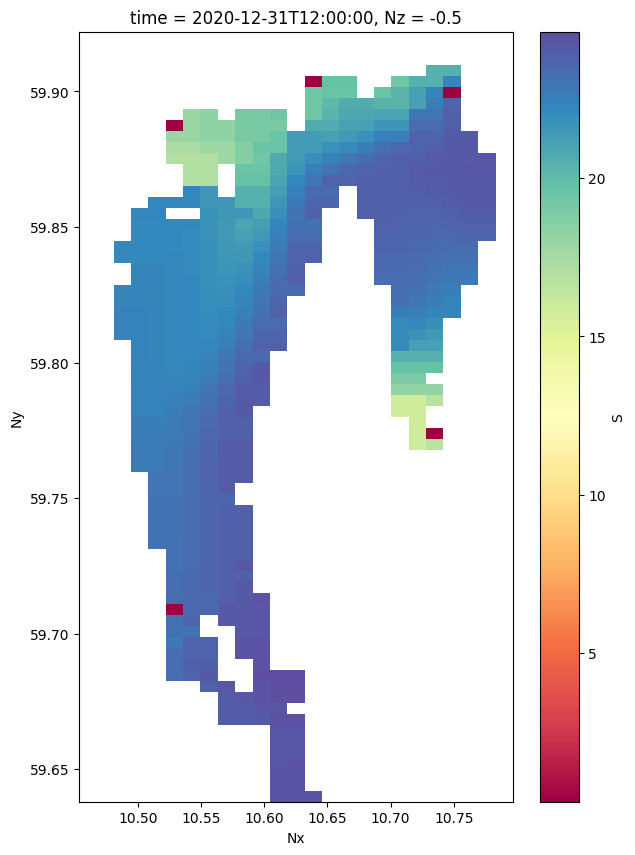

In [47]:
ds.S.isel(time=-1, Nz=-1).plot(cmap=mpl.colormaps.get_cmap("Spectral"), figsize=(7, 10))

In [48]:
for var in ds.data_vars:
    ds[var] = ds[var].astype(np.float32)

In [ ]:
ds

### Save

In [ ]:
encoding = {var: {"zlib": True, "complevel": 5} for var in ds.data_vars}
ds.to_netcdf(
    os.path.join(Path.home(), "src" , "oslofjord-sim" , "data" , "input" , "forcing_25to70.nc"),
    encoding=encoding,
)